In [1]:
import pandas as pd
#df.to_pickle("filepath/filename.pkl")
df = pd.read_pickle("Aer_Results.pkl")
df.head(10)

,Bond Length,Results,Ground State Energy (Hartree),Time (s),Nuclear Repulsion Energy (Hartree),Electronic Energies (Hartree),Convergence History,optimal_parameters_list
0,0.45,"{'x': [0.11733205617759934, -0.004944807436667...",-0.784527,63.004656,1.175949,-1.960476,"[-1.9498742420516766, -1.0972969792462033, -1....","[0.11733205617759934, -0.0049448074366672265, ..."
1,0.60,"{'x': [0.04252176478985217, -0.057628726192605...",-0.954613,51.765100,0.881962,-1.836575,"[-1.8133194057361917, -1.1397561424345366, -1....","[0.04252176478985217, -0.05762872619260512, -0..."
2,0.75,"{'x': [0.08194269846011225, 0.0272172181640434...",-1.004755,49.225971,0.705570,-1.710325,"[-1.6889662086102541, -1.1607485450462787, -1....","[0.08194269846011225, 0.02721721816404345, -0...."
3,0.90,"{'x': [0.12414550664799487, -0.100732845576297...",-1.004007,50.001643,0.587975,-1.591981,"[-1.575860011673866, -1.1412688563113418, -1.1...","[0.12414550664799487, -0.10073284557629796, -0..."
4,1.05,"{'x': [-0.05427685057278046, -0.06306770889962...",-0.995788,59.477210,0.503978,-1.499766,"[-1.4925456872797114, -1.1260575737250975, -1....","[-0.05427685057278046, -0.06306770889962647, -..."
5,1.20,"{'x': [0.0020581042898983083, -0.0003764385864...",-0.964422,54.260349,0.440981,-1.405403,"[-1.394259034323657, -1.0932479528548402, -1.1...","[0.0020581042898983083, -0.0003764385864734043..."
6,1.35,"{'x': [0.04068337562151455, -0.071949355294356...",-0.952746,48.857448,0.391983,-1.344729,"[-1.32179592387415, -1.072349752811254, -1.082...","[0.04068337562151455, -0.07194935529435663, -0..."
7,1.50,"{'x': [0.04977881051051476, -0.063046155234241...",-0.931695,52.312458,0.352785,-1.284480,"[-1.2473013496862853, -1.0330391305356237, -1....","[0.04977881051051476, -0.06304615523424176, -0..."


In [2]:
initial_parameters_dict = df.set_index("Bond Length")["optimal_parameters_list"].to_dict()
print(initial_parameters_dict)

{0.45: array([ 0.11733206, -0.00494481, -0.11223316]), 0.6: array([ 0.04252176, -0.05762873, -0.0227211 ]), 0.75: array([ 0.0819427 ,  0.02721722, -0.13657087]), 0.9: array([ 0.12414551, -0.10073285, -0.1197472 ]), 1.05: array([-0.05427685, -0.06306771, -0.16904842]), 1.2: array([ 0.0020581 , -0.00037644, -0.35084167]), 1.35: array([ 0.04068338, -0.07194936, -0.33842364]), 1.5: array([ 0.04977881, -0.06304616, -0.3439436 ])}


In [3]:
# from qiskit_ibm_runtime import QiskitRuntimeService

# # Account 1
# QiskitRuntimeService.save_account(
#     channel="ibm_quantum_platform",
#     token="####",
#     name="TJ"
# )

In [4]:
from qiskit_ibm_runtime import QiskitRuntimeService, Estimator

service = QiskitRuntimeService(name="TJ")
service.active_account()
print('Available backends:')
print(service.backends(simulator=False, operational=True))



qiskit_runtime_service.__init__:WARNING:2026-05-08 10:29:07,096: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-05-08 10:29:07,110: Loading instance: open-instance, plan: open


Available backends:
[<IBMBackend('ibm_fez')>, <IBMBackend('ibm_marrakesh')>, <IBMBackend('ibm_kingston')>]


In [5]:
backend = service.backend("ibm_fez")
print(f"Backend = {backend.name}")

qiskit_runtime_service.backends:WARNING:2026-05-08 10:29:10,478: Using instance: open-instance, plan: open


Backend = ibm_fez


## For Compiling on QPU


In [6]:
from qiskit_ibm_runtime import EstimatorV2
from qiskit_ibm_runtime.options import EstimatorOptions

options = EstimatorOptions()

# Set top-level attributes
options.default_shots = 1024
options.resilience_level = 2  # Turns on Zero Noise Extrapolation (ZNE)

# Access nested configurations for advanced resilience/twirling
options.resilience.zne_mitigation = True
options.twirling.enable_gates = True

estimatorv2 = EstimatorV2(mode=backend, options=options)
estimatorv1 = Estimator(mode=backend)    
# Level 2 turns on Zero Noise Extrapolation (ZNE) automatically
# Level 3 forces the cloud to transpile, optimize, and apply Dynamical Decoupling natively


## Local Compilation

In [7]:
# 
# from qiskit_aer import AerSimulator

# # Import an estimator, this time from qiskit (we will import from Runtime for real hardware)
# from qiskit.primitives import BackendEstimatorV2

# # generate a simulator that mimics the real quantum system
# backend_sim = AerSimulator.from_backend(backend)
# estimator = BackendEstimatorV2(backend=backend_sim)


In [ ]:
import numpy as np
import pandas as pd

from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit



from qiskit_nature.second_q.mappers import JordanWignerMapper
base_mapper = JordanWignerMapper()



from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD
num_spatial_orbitals = 2
num_particles = (1, 1)

from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA

from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from scipy.optimize import minimize

from qiskit.transpiler import PassManager
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)


from time import time


energies = []
ground_energies = []
optimizer_times = []
iteration_number = []
optimizer_results = []
nuclear_repulsion_energies = []
energy_histories = []
optimal_parameters_list = []


# Bond lengths in Angstrom
bond_lengths = np.array([0.90])


for r in bond_lengths:
    # Define H2 geometry
    geometry = f"H 0 0 0; H 0 0 {r}"

    # PySCF driver
    driver = PySCFDriver(
        atom=geometry,
        basis="sto3g",
        spin=0,
        charge=0,
        unit=DistanceUnit.ANGSTROM,
    )

    # Run electronic structure calculation
    problem = driver.run()

    tapered_mapper = problem.get_tapered_mapper(base_mapper)

    ansatz = UCCSD(
        num_spatial_orbitals,
        num_particles,
        tapered_mapper,
        initial_state=HartreeFock(
        num_spatial_orbitals,
        num_particles,
        tapered_mapper,
            ),
        )
    ansatz_isa = pm.run(ansatz)
    nuclear_repulsion = problem.hamiltonian.nuclear_repulsion_energy

    initial_parameters = initial_parameters_dict[r]

    print(f"Running VQE for bond length {r} Å with initial parameters: {initial_parameters}")

    vqe_solver = VQE(estimatorv1, ansatz, COBYLA())
    vqe_solver.initial_point = initial_parameters      # IMPORTANT
    x0 = vqe_solver.initial_point

    solver = GroundStateEigensolver(tapered_mapper, vqe_solver)

    main_operator, aux_ops = solver.get_qubit_operators(problem)

    H = main_operator
    hamiltonian_isa = H.apply_layout(ansatz_isa.layout)

    energy_history = []

    def cost_func(params, ansatz, H, estimator):
        pub = (ansatz, H, params)
        result = estimator.run(pubs=[pub]).result()
        energy = result[0].data.evs[0]
        energy_history.append(energy)  
        return energy

    start_time = time()
    result = minimize(
        cost_func,
        x0,
        args=(ansatz_isa, hamiltonian_isa, estimatorv2),
        method="cobyla",
        options={"maxiter": 10, "disp": True},)

    optimizer_time = time() - start_time
    energy = result.fun
    optimal_parameters = result.x
    ground_state_energy = energy + nuclear_repulsion
    print(f"Nuclear Repulsion Energy = {nuclear_repulsion:.6f} Hartree")
    print(f"Electronic Energy = {energy:.6f} Hartree")
    print(f"Ground state energy for bond length {r} Å: {ground_state_energy:.6f} Hartree")



    energies.append(energy)
    ground_energies.append(ground_state_energy)
    optimizer_results.append(result)
    optimizer_times.append(optimizer_time)
    nuclear_repulsion_energies.append(nuclear_repulsion)
    iteration_number.append(result.nfev)
    energy_histories.append(energy_history)
    optimal_parameters_list.append(optimal_parameters)





Running VQE for bond length 0.9 Å with initial parameters: [ 0.12414551 -0.10073285 -0.1197472 ]
Return from COBYLA because the objective function has been evaluated MAXFUN times.
Number of function values = 15   Least value of F = -1.7089164323355601
The corresponding X is:
[-0.13172366  0.88820907  0.02682317]

Nuclear Repulsion Energy = 0.587975 Hartree
Electronic Energy = -1.708916 Hartree
Ground state energy for bond length 0.9 Å: -1.120942 Hartree


In [9]:

# Create table
df = pd.DataFrame({
    "Bond Length": bond_lengths,
    "Results": optimizer_results,
    "Ground State Energy (Hartree)": ground_energies,
    "Time (s)": optimizer_times,
    "Nuclear Repulsion Energy (Hartree)": nuclear_repulsion_energies,
    "Electronic Energies (Hartree)": energies,
    "Convergence History": energy_histories,
    "optimal_parameters_list": optimal_parameters_list
})
df.head()

,Bond Length,Results,Ground State Energy (Hartree),Time (s),Nuclear Repulsion Energy (Hartree),Electronic Energies (Hartree),Convergence History,optimal_parameters_list
0,0.9,"{'x': [-0.13172365673831438, 0.888209071803486...",-1.120942,464.189313,0.587975,-1.708916,"[-1.6037634524908038, -0.5310636169684356, -1....","[-0.13172365673831438, 0.8882090718034867, 0.0..."


In [10]:
df.to_pickle("Bond_90/Result_dataframe.pkl")

ansatz depth = 8


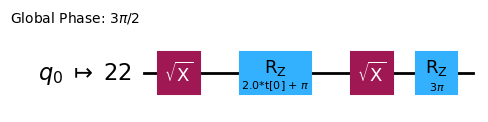

In [11]:
print(f"ansatz depth = {ansatz_isa.decompose().depth()}")
ansatz_isa.draw(output="mpl", idle_wires=False, style="iqp")

In [12]:
# Saving Data
import os
import pickle
import json
from qiskit import qpy

save_dir = "Bond_90/"
os.makedirs(save_dir, exist_ok=True)

# -----------------------------
# 1. Save optimizer result
# -----------------------------
with open(os.path.join(save_dir, "optimizer_result.pkl"), "wb") as f:
    pickle.dump(result, f)

# -----------------------------
# 2. Save optimized parameters
# -----------------------------
optimal_parameters = result.x
with open(os.path.join(save_dir, "optimal_parameters.pkl"), "wb") as f:
    pickle.dump(optimal_parameters, f)

# -----------------------------
# 3. Save Hamiltonian
# -----------------------------
with open(os.path.join(save_dir, "hamiltonian.pkl"), "wb") as f:
    pickle.dump(hamiltonian_isa, f)

# -----------------------------
# 4. Save Ansatz Circuit
# -----------------------------
with open(os.path.join(save_dir, "ansatz.qpy"), "wb") as f:
    qpy.dump(ansatz_isa, f)

# -----------------------------
# 5. Save backend information
# -----------------------------
backend_info = {
    "backend_name": backend.name,
    "num_qubits": backend.num_qubits,
    "version": backend.version,
}

with open(os.path.join(save_dir, "backend_info.json"), "w") as f:
    json.dump(backend_info, f, indent=4)

# -----------------------------
# 6. Save experiment metadata
# -----------------------------
experiment_metadata = {
    "bond_length": float(r),
    "basis": "sto3g",
    "shots": 1024,
    "optimizer": "COBYLA",
    "maxiter": 10,
    "energy": float(energy),
    "ground_state_energy": float(ground_state_energy),
    "nuclear_repulsion_energy": float(nuclear_repulsion),
    "iterations": result.nfev,
    "optimizer_success": result.success,
    "backend": backend.name
}

with open(os.path.join(save_dir, "experiment_metadata.pkl"), "wb") as f:
    pickle.dump(experiment_metadata, f)

# -----------------------------
# 7. Save DataFrame results
# -----------------------------
df.to_pickle(os.path.join(save_dir, "results_dataframe.pkl"))
df.to_csv(os.path.join(save_dir, "results_dataframe.csv"), index=False)

# -----------------------------
# 8. Save additional circuit info
# -----------------------------
circuit_info = {
    "num_qubits": ansatz_isa.num_qubits,
    "num_parameters": ansatz_isa.num_parameters,
    "circuit_depth": ansatz_isa.depth()
}

with open(os.path.join(save_dir, "circuit_info.json"), "w") as f:
    json.dump(circuit_info, f, indent=4)


print(save_dir)

Bond_90/


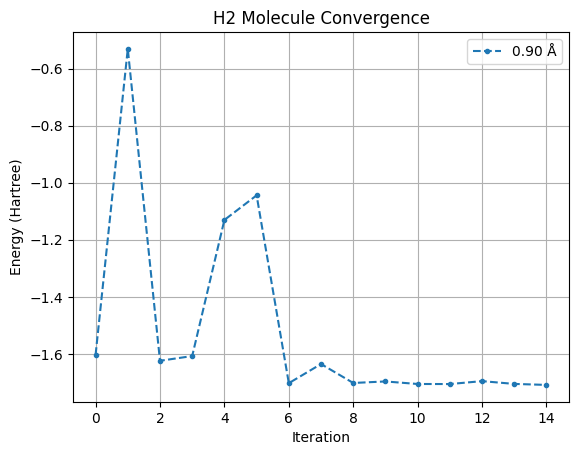

In [13]:
import matplotlib.pyplot as plt
plt.plot(energy_history, marker='.', linestyle='--')
plt.grid(True)
plt.xlabel("Iteration")
plt.ylabel("Energy (Hartree)")
plt.title("H2 Molecule Convergence")
plt.legend([f"{r:.2f} Å" for r in bond_lengths])
plt.show()